# Regression discontinuity design (RDD)

In [1]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from tabulate import tabulate

In [2]:
np.random.seed(12282020)

# draw a random variable X from a random distribution
# mean = 50
# standard deviation = 25
# Size = 1000
mu_X = 50
sd_X = 25
N_X = 1000
c_0 = 50

# generate random X values
df = pd.DataFrame({'X': np.random.normal(mu_X, sd_X, N_X)})
# for this example, replace X < 0 with 0
df.loc[df['X'] < 0] = 0
# for this example, drop x > 100
drop_idx = df.loc[df['X'] > 100].index
df = df.drop(index=drop_idx)

# set the cutoff at 50; treated if X > 50
df['D'] = (df['X'] > c_0)

# generate potential outcomes
alpha = 25
beta = 1.5
delta = 40
epsilon = np.random.normal(0, 20, len(df))
df['Y_0'] = alpha + beta * df['X'] + epsilon
df['Y_1'] = alpha + beta * df['X'] + delta + epsilon

df['Y'] = alpha + beta * df['X'] + delta * df['D'] + epsilon

df.head()

,X,D,Y_0,Y_1,Y
0,80.208285,True,157.689643,197.689643,197.689643
1,51.326053,True,85.135704,125.135704,125.135704
2,64.770307,True,98.997924,138.997924,138.997924
3,44.157556,False,89.409646,129.409646,89.409646
4,44.039981,False,83.927971,123.927971,83.927971


Text(0.5, 0, 'Test Score ($X$)')

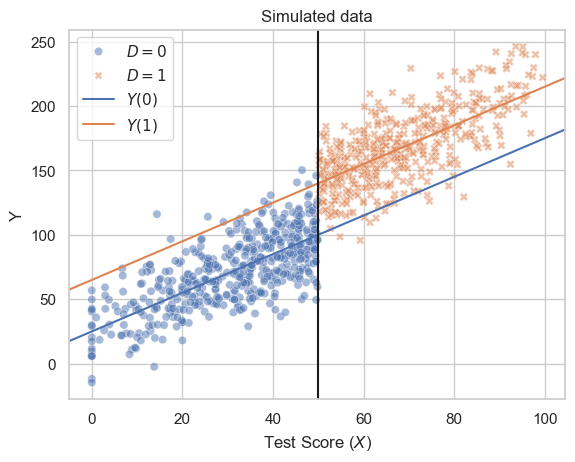

In [3]:
# set up figure and axes
fig, ax = plt.subplots()

# define the scatterplot with observed values
sns.scatterplot(
    data=df,
    x='X',
    y='Y',
    hue='D',    # different colors for markers for different D
    style='D',  # different marker styles for different D
    ax=ax,      # add to existing axes ax
    alpha=0.5   # makes the scatter points a bit transparent
    
)

# get minimum and maximum of axes
x_min, x_max = ax.get_xlim()

# create an array with evenly spaced values over the x axis
x_array = np.linspace(x_min, x_max, 100)
# calculate the control potential outcome for this x_array
y_0 = alpha + beta * x_array
# calcualte the treatment potential outcome for this x_array
y_1 = y_0 + delta

# add these lines to the plot
sns.lineplot(x=x_array, y=y_0, label='$Y (0)$', ax=ax)
sns.lineplot(x=x_array, y=y_1, label='$Y (1)$', ax=ax)

# get all the legend handles (markers) and labels
handles, labels = ax.get_legend_handles_labels()

# create a dictionary with new dictionary labels
replace_label_dict = {
    'False': '$D=0$', 'True': '$D=1$',          # these are the labels i want to change
    '$Y (0)$': '$Y (0)$', '$Y (1)$': '$Y (1)$'  # these are staying the same
}
new_labels = [replace_label_dict[label] for label in labels if label in replace_label_dict.keys()]
# add new labels and original handles back to the plot
ax.legend(labels=new_labels, handles=handles)

# remove some padding from the figure
ax.set_xlim(x_min, x_max)

# add a vertical line at 50
ax.axvline(c_0, color='k')

# set the title of the figure
ax.set_title('Simulated data')
ax.set_xlabel('Test Score ($X$)')

In [4]:
# create an array with evenly spaced values over the x axis
x_0_array = np.linspace(x_min, c_0, 100)
# calculate the control potential outcome for this x_array
y_0 = alpha + beta * x_array

x_1_array = np.linspace(c_0, x_max, 100)
# calcualte the treatment potential outcome for this x_array
y_1 = alpha + beta * x_array + delta

Text(0.5, 0, 'Test Score ($X$)')

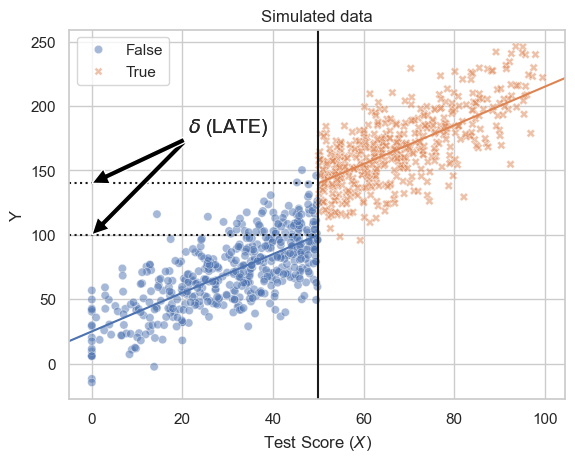

In [5]:
# set up figure and axes
fig, ax = plt.subplots()

# define the scatterplot with observed values
sns.scatterplot(
    data=df,
    x='X',
    y='Y',
    hue='D',    # different colors for markers for different D
    style='D',  # different marker styles for different D
    ax=ax,      # add to existing axes ax
    alpha=0.5   # makes the scatter points a bit transparent
    
)

# get minimum and maximum of axes
x_min, x_max = ax.get_xlim()

# create an array with evenly spaced values over the x axis below c_0
x_0_array = np.linspace(x_min, c_0, 100)
# calculate the control potential outcome for this x_array above c_0
y_0 = alpha + beta * x_0_array

x_1_array = np.linspace(c_0, x_max, 100)
# calcualte the treatment potential outcome for this x_array
y_1 = alpha + beta * x_1_array + delta

# add these lines to the plot
sns.lineplot(x=x_0_array, y=y_0, ax=ax)
sns.lineplot(x=x_1_array, y=y_1, ax=ax)

# 
# ax.hlines(y=())

ax.hlines(y=(alpha + beta * c_0), xmin=x_min, xmax=c_0, color='k', linestyles=':')
ax.hlines(y=(alpha + beta * c_0 + delta), xmin=x_min, xmax=c_0, color='k', linestyles=':')

# remove some padding from the figure
ax.set_xlim(x_min, x_max)

y_label_point = ((y_0[-1] + y_1[0])/2)-5
ax.annotate(
    '$\delta$ (LATE)', 
    xy=(0, y_0[-1]),
    xytext=(30, 175),
    fontsize=14, ha='center', va='bottom', 
    arrowprops=dict(facecolor='black', lw=1.0),
    # arrowprops=dict(arrowstyle='-[, widthB=5.0, lengthB=.5', lw=2.0)
)
ax.annotate(
    '$\delta$ (LATE)', 
    # '',
    xy=(0, y_1[0]),
    xytext=(30, 175),
    fontsize=14, ha='center', va='bottom', 
    arrowprops=dict(facecolor='black', lw=1.0),
    horizontalalignment='right'
)
# add a vertical line at 50
ax.axvline(c_0, color='k')

# set the title of the figure
ax.set_title('Simulated data')
ax.set_xlabel('Test Score ($X$)')


## Sharp RDD

In [6]:
url = "https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/master/causal-inference-for-the-brave-and-true/data/drinking.csv"
df = pd.read_csv(url)

print(tabulate(df[["agecell", "all", "mva", "suicide"]].head(), headers='keys', showindex=False))

# re-center running variable
df['D'] = df['agecell'] > 21
df['agecell'] = df['agecell'] - 21

print(tabulate(df[["agecell", "all", "mva", "suicide", 'D']].head(), headers='keys', showindex=False))

  agecell      all      mva    suicide
---------  -------  -------  ---------
  19.0685  92.8254  35.8293    11.2037
  19.1507  95.1007  35.6393    12.1934
  19.2329  92.1443  34.2056    11.7158
  19.3151  88.4278  32.279     11.275
  19.3973  88.7049  32.651     10.9843
  agecell      all      mva    suicide  D
---------  -------  -------  ---------  -----
 -1.93151  92.8254  35.8293    11.2037  False
 -1.84932  95.1007  35.6393    12.1934  False
 -1.76712  92.1443  34.2056    11.7158  False
 -1.68493  88.4278  32.279     11.275   False
 -1.60274  88.7049  32.651     10.9843  False


Text(0.5, 1.0, 'Death cause by age (centered at 0)')

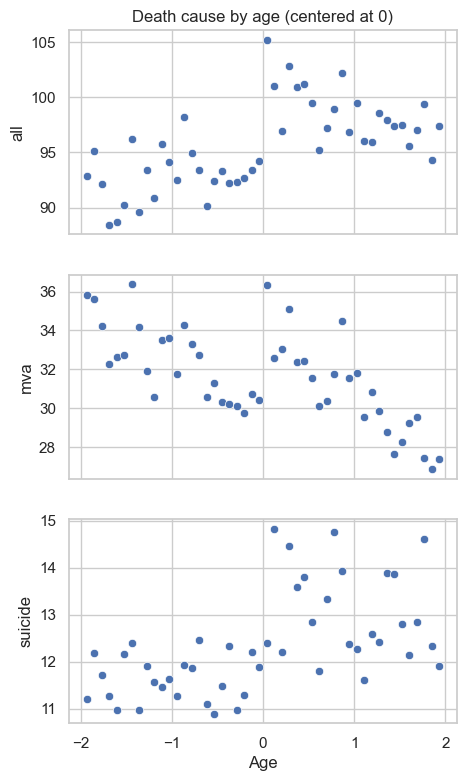

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

sns.scatterplot(data=df, x='agecell', y='all', ax=axes[0])

sns.scatterplot(data=df, x='agecell', y='mva', ax=axes[1])

sns.scatterplot(data=df, x='agecell', y='suicide', ax=axes[2])

axes[2].set_xlabel('Age')

axes[0].set_title('Death cause by age (centered at 0)')

In [8]:
wls_mod = smf.wls('all ~ D * agecell', data=df)
wls_res = wls_mod.fit()

print(
    f"Mortality increases by {wls_res.params['D[T.True]']:.2f} points with legal consumption of alcohol"
)

perc_change = 100 * (((wls_res.params['Intercept'] + wls_res.params['D[T.True]']) / wls_res.params['Intercept']) - 1)
print(f"Percent_change: {perc_change:.2f}%")

wls_res.summary(slim=True)

Mortality increases by 7.66 points with legal consumption of alcohol
Percent_change: 8.19%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                    all   R-squared:                       0.668
Model:                            WLS   Adj. R-squared:                  0.645
No. Observations:                  48   F-statistic:                     29.47
Covariance Type:            nonrobust   Prob (F-statistic):           1.33e-10
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            93.6184      0.932    100.399      0.000      91.739      95.498
D[T.True]             7.6627      1.319      5.811      0.000       5.005      10.320
agecell               0.8270      0.819      1.010      0.318      -0.823       2.477
D[T.True]:agecell    -3.6034      1.158     -3.111      0.003      -5.937      -1.269
=====================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='agecell', ylabel='all'>

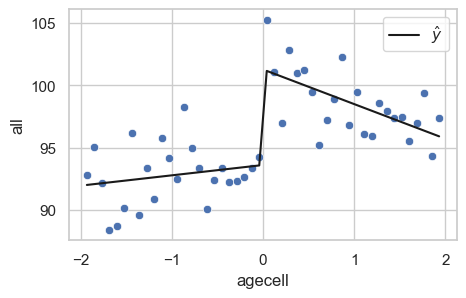

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=df, x='agecell', y='all', ax=ax)

sns.lineplot(x=df['agecell'], y=wls_res.fittedvalues, color='k', label='$\hat{y}$')

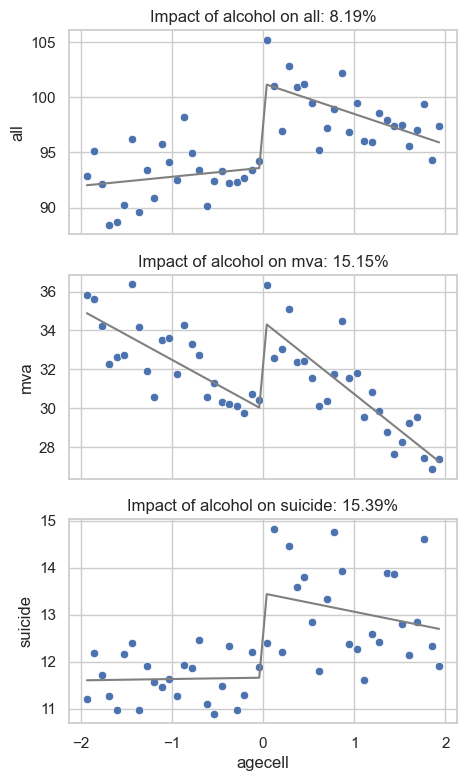

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

for i, y_var in enumerate(['all', 'mva', 'suicide']):

    wls_mod = smf.wls(f'{y_var} ~ D * agecell', data=df)
    wls_res = wls_mod.fit()

    # print(
    #     f"Mortality increases by {wls_res.params['D[T.True]']:.2f} points with legal consumption of alcohol"
    # )

    perc_change = 100 * (((wls_res.params['Intercept'] + wls_res.params['D[T.True]']) / wls_res.params['Intercept']) - 1)
    # print(f"Percent_change: {perc_change:.2f}%")
    axes[i].set_title(f'Impact of alcohol on {y_var}: {perc_change:.2f}%')

    # wls_res.summary(slim=True)

    sns.scatterplot(data=df, x='agecell', y=y_var, ax=axes[i])
    sns.lineplot(x=df['agecell'], y=wls_res.fittedvalues, color='gray', ax=axes[i])
    # axes[i].axvline(0, color='k')


    

### Kernel weighting

In [11]:
def kernel(R, c, h):
    indicator = (np.abs(R-c) <= h).astype(float)
    return indicator * (1 - np.abs(R-c)/h)

Text(0.5, 1.0, 'Kernel by weight')

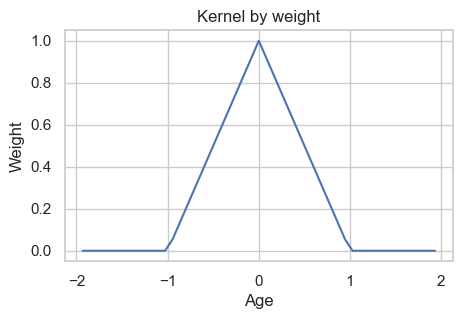

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(df['agecell'], kernel(df['agecell'], c=0, h=1))
ax.set_xlabel('Age')
ax.set_ylabel('Weight')
ax.set_title('Kernel by weight')

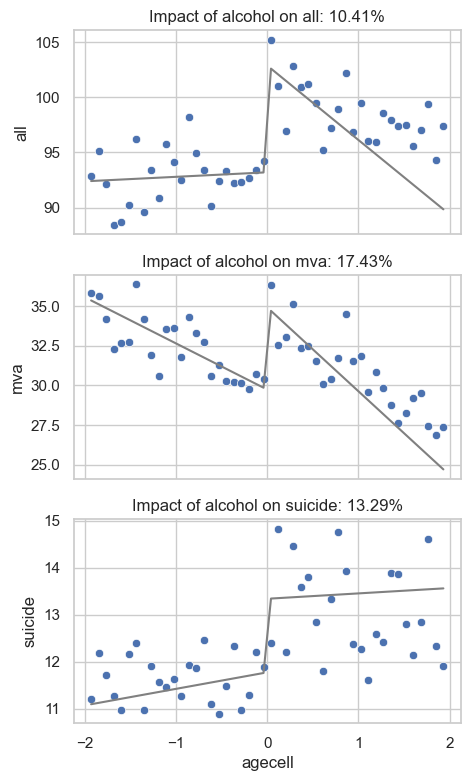

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

for i, y_var in enumerate(['all', 'mva', 'suicide']):

    wls_mod = smf.wls(f'{y_var} ~ D * agecell', df, weights=kernel(df['agecell'], c=0, h=1))
    wls_res = wls_mod.fit()

    # print(
    #     f"Mortality increases by {wls_res.params['D[T.True]']:.2f} points with legal consumption of alcohol"
    # )

    perc_change = 100 * (((wls_res.params['Intercept'] + wls_res.params['D[T.True]']) / wls_res.params['Intercept']) - 1)
    # print(f"Percent_change: {perc_change:.2f}%")
    axes[i].set_title(f'Impact of alcohol on {y_var}: {perc_change:.2f}%')

    # wls_res.summary(slim=True)

    sns.scatterplot(data=df, x='agecell', y=y_var, ax=axes[i])
    sns.lineplot(x=df['agecell'], y=wls_res.fittedvalues, color='gray', ax=axes[i])
    # axes[i].axvline(0, color='k')


    

## Replication

In [14]:
# Function to generate significance stars
def get_significance_stars(pval):
    if pval < 0.001:
        return '****'
    elif pval < 0.01:
        return '***'
    elif pval < 0.05:
        return '**'
    elif pval < 0.1:
        return '*'
    else:
        return ''

In [15]:
# combining the above into a function
def get_result_array(res, keep_vars, name=None):
    coef_series = (
        res.params[keep_vars].round(1).astype(str)           # format the estimated parameters as rounded strings
        +                                                        # use addition to add stars (if any)
        res.pvalues.apply(get_significance_stars)[keep_vars] # generate significance stars
    )
    coef_series.name = 'coef'  # naming series will be helpful when this is a dataframe
    tvalue_series = '(' + res.bse[keep_vars].round(2).astype(str) + ')' # add parentheses around formatted t-values
    tvalue_series.name = 'se'
    obs_series = pd.Series([f'{res.nobs:.0f}'], index=['_nobs'], name='obs')

    ols_res_series = pd.concat([coef_series, tvalue_series, obs_series]).sort_index(ascending=False)
    if name is not None:
        ols_res_series.name = name

    # reorder index
    index_order = keep_vars + ['_nobs']
    ols_res_series = ols_res_series.loc[index_order]
    
    return ols_res_series

In [16]:
url = "https://github.com/scunning1975/mixtape/raw/master/lmb-data.dta"
df_orig = pd.read_stata(url)

In [17]:
df = df_orig.copy()
df['demvoteshare_c'] = df['demvoteshare'] - 0.5

In [18]:
# lm1 = rdd_reg(y='score', x=['lagdemocrat', 'demvoteshare_c'], df=df_subset)
# df=df_subset.copy()
y='score'
x=['lagdemocrat', 'demvoteshare_c']

# def rdd_reg(y, x, df, group='id'):
reg_rhs = ' + '.join(x)
wls_mod = smf.wls(f'{y} ~ {reg_rhs}', data = df)

# lm = get_result_array(wls_fit, keep_vars=x)
# lm.index = ['coef', 'se', '_n']

def rdd_reg(y, x, df, group='id', join_str = ' + ', reg_str=None):
    # copy, because you may have to drop variables
    df=df.copy()
    # conver the x list to a string: ['x1', 'x2'] > 'x1 + x2'
    if reg_str is None:
        reg_rhs = join_str.join(x)
        reg_str = f'{y} ~ {reg_rhs}'
    # establish innitial regression model
    wls_mod = smf.wls(reg_str, data = df)
    # check if there are missing rows that will stop you from fitting robust se
    if len(wls_mod.data.missing_row_idx) > 0:
        # if so, create a new subset, and re-creat model
        df = df.drop(index=wls_mod.data.missing_row_idx).copy()
        wls_mod = smf.wls(f'{y} ~ {reg_rhs}', data = df)
    # fit model with robust standard errors
    wls_fit = wls_mod.fit(cov_type='cluster', cov_kwds={'groups': df[group]})
    # keep everything but the intercept
    x_keep_var = [x for x in wls_fit.params.index if x != 'Intercept']
    lm = get_result_array(wls_fit, keep_vars=x_keep_var)
    # lm.index = ['coef', 'se', '_n']
    return lm

In [19]:
df_subset = df.loc[df['lagdemvoteshare'].between(.48, .52)].copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id']].dropna()

lm1 = rdd_reg(y='score', x=['lagdemocrat'], df=df_subset)
lm1.name = 'ADA_{t+1}'
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat'], df=df_subset)
lm2.name = 'ADA_{t+1}'
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat'], df=df_subset)
lm3.name = 'Dem_{t+1}'
lm3.index = ['_coef', '_se', 'N']

print('Original results based on ADA Scores – Close Elections Sample')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))



Original results based on ADA Scores – Close Elections Sample
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  21.3****     47.7****     0.5****
_se    (1.95)       (1.36)       (0.03)
N      915          915          915


In [20]:
df_subset = df.copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id']].dropna()

lm1 = rdd_reg(y='score', x=['lagdemocrat'], df=df_subset)
lm1.name = 'ADA_{t+1}'
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat'], df=df_subset)
lm2.name = 'ADA_{t+1}'
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat'], df=df_subset)
lm3.name = 'Dem_{t+1}'
lm3.index = ['_coef', '_se', 'N']

print('Results based on ADA Scores – Full Sample ')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))

Results based on ADA Scores – Full Sample 
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  31.5****     40.8****     0.8****
_se    (0.48)       (0.42)       (0.01)
N      13577        13577        13577


In [21]:
df_subset = df.copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id', 'demvoteshare_c']].dropna()

lm1 = rdd_reg(y='score', x=['lagdemocrat', 'demvoteshare_c'], df=df_subset)
lm1.name = 'ADA_{t+1}'
lm1.drop(index='demvoteshare_c', inplace=True)
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat', 'demvoteshare_c'], df=df_subset)
lm2.name = 'ADA_{t+1}'
lm2.drop(index='demvoteshare_c', inplace=True)
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat', 'demvoteshare_c'], df=df_subset)
lm3.name = 'Dem_{t+1}'
lm3.drop(index='demvoteshare_c', inplace=True)
lm3.index = ['_coef', '_se', 'N']

print('Results based on ADA Scores – Full Sample ')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))



Results based on ADA Scores – Full Sample 
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  33.5****     58.5****     0.6****
_se    (0.85)       (0.66)       (0.01)
N      13577        13577        13577


In [22]:
df_subset = df.copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id', 'demvoteshare_c']].dropna()

lm1 = rdd_reg(y='score', x=['lagdemocrat', 'demvoteshare_c'], df=df_subset, join_str='*')
lm1.name = 'ADA_{t+1}'
lm1.drop(index=['demvoteshare_c', 'lagdemocrat:demvoteshare_c'], inplace=True)
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat', 'demvoteshare_c'], df=df_subset, join_str='*')
lm2.name = 'ADA_{t+1}'
lm2.drop(index=['demvoteshare_c', 'democrat:demvoteshare_c'], inplace=True)
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat', 'demvoteshare_c'], df=df_subset, join_str='*')
lm3.name = 'Dem_{t+1}'
lm3.drop(index=['demvoteshare_c', 'lagdemocrat:demvoteshare_c'], inplace=True)
lm3.index = ['_coef', '_se', 'N']

print('Results based on ADA Scores – Full Sample with linear interactions')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))

Results based on ADA Scores – Full Sample with linear interactions
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  30.5****     55.4****     0.5****
_se    (0.82)       (0.64)       (0.01)
N      13577        13577        13577


In [23]:
df_subset = df.copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id', 'demvoteshare_c']].dropna()
df_subset['demvoteshare_sq'] = df_subset['demvoteshare_c']**2

lm1 = rdd_reg(y='score', x=['lagdemocrat', 'demvoteshare_c', 'demvoteshare_sq'],
              df=df_subset, reg_str='score ~ lagdemocrat*demvoteshare_c + lagdemocrat*demvoteshare_sq')
lm1.name = 'ADA_{t+1}'
lm1 = lm1[['lagdemocrat', '_nobs']]
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat', 'demvoteshare_c', 'demvoteshare_sq'], 
              df=df_subset, reg_str='score ~ democrat*demvoteshare_c + democrat*demvoteshare_sq')
lm2.name = 'ADA_{t+1}'
lm2 = lm2[['democrat', '_nobs']]
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat', 'demvoteshare_c', 'demvoteshare_sq'], 
              df=df_subset, reg_str='democrat ~ lagdemocrat*demvoteshare_c + lagdemocrat*demvoteshare_sq')
lm3.name = 'Dem_{t+1}'
lm3 = lm3[['lagdemocrat', '_nobs']]
lm3.index = ['_coef', '_se', 'N']

print('Results based on ADA Scores – Full Sample with linear and quadratic interactions')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))

Results based on ADA Scores – Full Sample with linear and quadratic interactions
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  13.0****     44.4****     0.3****
_se    (1.27)       (0.91)       (0.02)
N      13577        13577        13577


In [24]:
df_subset = df.loc[df['lagdemvoteshare'].between(.48, .52)].copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id', 'demvoteshare_c']].dropna()
df_subset['demvoteshare_sq'] = df_subset['demvoteshare_c']**2

lm1 = rdd_reg(y='score', x=['lagdemocrat', 'demvoteshare_c', 'demvoteshare_sq'],
              df=df_subset, reg_str='score ~ lagdemocrat*demvoteshare_c + lagdemocrat*demvoteshare_sq')
lm1.name = 'ADA_{t+1}'
lm1 = lm1[['lagdemocrat', '_nobs']]
lm1.index = ['_coef', '_se', 'N']

lm2 = rdd_reg(y='score', x=['democrat', 'demvoteshare_c', 'demvoteshare_sq'], 
              df=df_subset, reg_str='score ~ democrat*demvoteshare_c + democrat*demvoteshare_sq')
lm2.name = 'ADA_{t+1}'
lm2 = lm2[['democrat', '_nobs']]
lm2.index = ['_coef', '_se', 'N']

lm3 = rdd_reg(y='democrat', x=['lagdemocrat', 'demvoteshare_c', 'demvoteshare_sq'], 
              df=df_subset, reg_str='democrat ~ lagdemocrat*demvoteshare_c + lagdemocrat*demvoteshare_sq')
lm3.name = 'Dem_{t+1}'
lm3 = lm3[['lagdemocrat', '_nobs']]
lm3.index = ['_coef', '_se', 'N']

print('Results based on ADA Scores – Full Sample with linear and quadratic interactions')
print_df = pd.concat([lm1, lm2, lm3], axis=1)
print(tabulate(print_df, headers='keys'))

Results based on ADA Scores – Full Sample with linear and quadratic interactions
       ADA_{t+1}    ADA_{t+1}    Dem_{t+1}
-----  -----------  -----------  -----------
_coef  4.1*         47.3****     0.1****
_se    (2.23)       (2.57)       (0.03)
N      915          915          915


In [25]:
def lm_robust(formula, data):
    regression = smf.wls(formula, data = data)
    regression = regression.fit(cov_type="cluster",cov_kwds={"groups":data['id']})
    return regression

df_subset = df.loc[df['lagdemvoteshare'].between(.45, .55)].copy()
# drop na values, otherwise python cannot cluster standard errors
df_subset = df_subset[['score', 'democrat', 'lagdemocrat', 'demvoteshare', 'id', 'demvoteshare_c', 'lagdemvoteshare']].dropna()
# df_subset['demvoteshare_sq'] = df_subset['demvoteshare_c']**2
df_subset['gg_group'] = (df_subset['lagdemvoteshare'] >= .5) * 1


# 100 categories in the specified range
df_subset['lagdemvoteshare_100'] = pd.cut(df_subset['lagdemvoteshare'], 100)
agg_df = df_subset.groupby('lagdemvoteshare_100', observed=False)['score'].mean().reset_index()
agg_df.sort_values(by='lagdemvoteshare_100', inplace=True)
agg_df['lagdemvoteshare'] = np.arange(0.01, 1.01, .01)


In [26]:
# import numpy as np 
# import pandas as pd 
# import statsmodels.api as sm 
# import statsmodels.formula.api as smf 
# from itertools import combinations 
# import plotnine as p

# # read data
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context
# def read_data(file): 
#     return pd.read_stata("https://github.com/scunning1975/mixtape/raw/master/" + file)

# def lm_robust(formula, data):
#     regression = sm.OLS.from_formula(formula, data = data)
#     regression = regression.fit(cov_type="cluster",cov_kwds={"groups":data['id']})
#     return regression


# lmb_data = read_data("lmb-data.dta")

# lmb_data['demvoteshare_c'] = lmb_data['demvoteshare'] - 0.5
# # drop missing values
# lmb_data = lmb_data[~pd.isnull(lmb_data.demvoteshare_c)]
# lmb_data['demvoteshare_sq'] = lmb_data['demvoteshare_c']**2

# #aggregating the data
# lmb_data = lmb_data[lmb_data.demvoteshare.between(.45, .55)]
# categories = lmb_data.lagdemvoteshare
# lmb_data['lagdemvoteshare_100'] = pd.cut(lmb_data.lagdemvoteshare, 100)

# agg_lmb_data = lmb_data.groupby('lagdemvoteshare_100')['score'].mean().reset_index()
# lmb_data['gg_group'] = [1 if x>.5 else 0 for x in lmb_data.lagdemvoteshare]
# agg_lmb_data['lagdemvoteshare'] = np.arange(0.01, 1.01, .01)

# # plotting
# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lm", 
#               formula = 'y ~ x + I(x**2)') +\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)

# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lowess") +\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)

# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lm")+\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)

In [27]:
# fig, ax = plt.subplots()

# # sns.catplot(data=agg_df, x='lagdemvoteshare_100', y='score', ax=ax)
# # agg_df['lagdemvoteshare_100']
# sns.scatterplot(data=agg_df, x='lagdemvoteshare', y='score')



In [28]:

# #aggregating the data
# lmb_data = df.loc[df['lagdemvoteshare'].between(.45, .55)].copy()
# categories = lmb_data.lagdemvoteshare
# lmb_data['lagdemvoteshare_100'] = pd.cut(lmb_data.lagdemvoteshare, 100)

# agg_lmb_data = lmb_data.groupby('lagdemvoteshare_100')['score'].mean().reset_index()
# lmb_data['gg_group'] = [1 if x>.5 else 0 for x in lmb_data.lagdemvoteshare]
# agg_lmb_data['lagdemvoteshare'] = np.arange(0.01, 1.01, .01)

In [29]:
# sns.scatterplot(agg_lmb_data, x='lagdemvoteshare', y='score')

In [30]:
# agg_lmb_data

In [31]:

# #aggregating the data

# agg_lmb_data = lmb_data.groupby('lagdemvoteshare_100')['score'].mean().reset_index()
# lmb_data['gg_group'] = [1 if x>.5 else 0 for x in lmb_data.lagdemvoteshare]
# agg_lmb_data['lagdemvoteshare'] = np.arange(0.01, 1.01, .01)

# # plotting
# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lm", 
#               formula = 'y ~ x + I(x**2)') +\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)

# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lowess") +\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)

# p.ggplot(lmb_data, p.aes('lagdemvoteshare', 'score')) +    p.geom_point(p.aes(x = 'lagdemvoteshare', y = 'score'), data = agg_lmb_data) +    p.stat_smooth(p.aes('lagdemvoteshare', 'score', group = 'gg_group'), 
#                   data=lmb_data, method = "lm")+\
#     p.xlim(0,1) + p.ylim(0,100) +\
#     p.geom_vline(xintercept = 0.5)